# Resume Screening / Classification — 01 Exploratory Data Analysis

A **text-classification** project that classifies resumes into job categories (e.g. Data Science, HR, Java Developer) from their text. **Multi-class** classification — 25 job categories.

We use a TF-IDF + classic-ML pipeline: this notebook explores the raw text and labels.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
%matplotlib inline
import utils

df=utils.load_data()
print('rows:',len(df),'| classes:',df['label'].nunique())
df.head(3)

rows: 962 | classes: 25


,label,text
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \nMay 2013 to May 2017 B.E ...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."


## 1. Class distribution

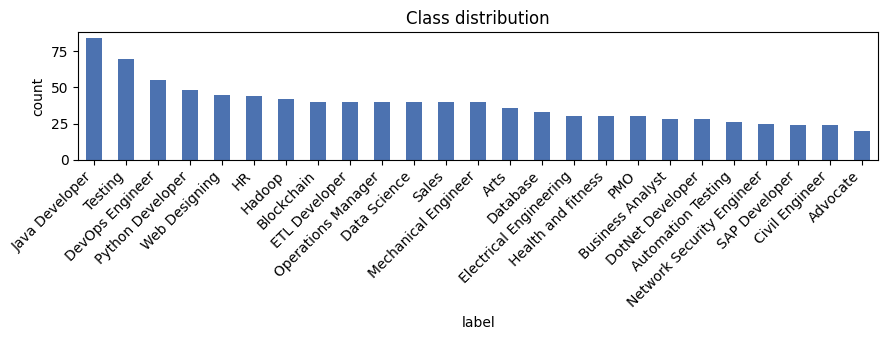

label
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20


In [2]:
fig,ax=plt.subplots(figsize=(9,3.5))
vc=df['label'].value_counts()
vc.plot(kind='bar',ax=ax,color='#4c72b0'); ax.set_title('Class distribution'); ax.set_ylabel('count')
plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()
print(vc.to_string())

## 2. Text length distribution

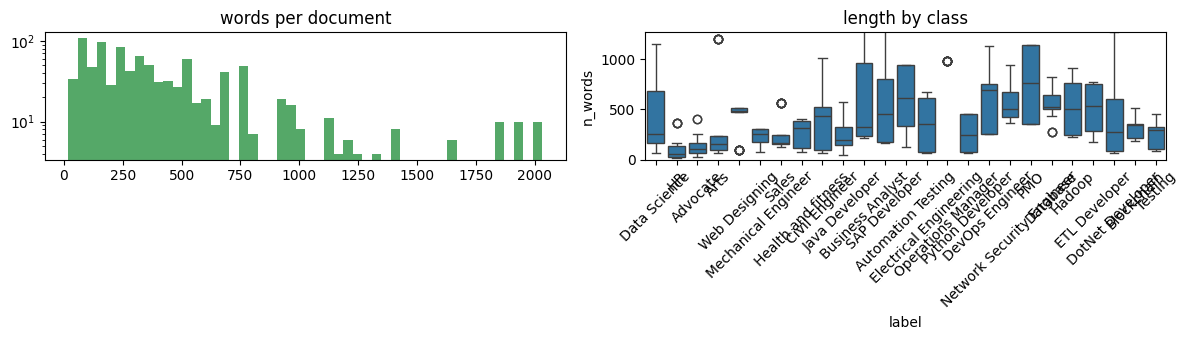

words per doc — median 329, max 2209


In [3]:
df['n_words']=df['text'].astype(str).str.split().apply(len)
fig,ax=plt.subplots(1,2,figsize=(12,3.5))
ax[0].hist(df['n_words'].clip(upper=df['n_words'].quantile(0.99)),bins=50,color='#55a868'); ax[0].set_title('words per document'); ax[0].set_yscale('log')
sns.boxplot(x='label',y='n_words',data=df,ax=ax[1]); ax[1].set_ylim(0,df['n_words'].quantile(0.95)); ax[1].set_title('length by class'); ax[1].tick_params(axis='x',rotation=45)
plt.tight_layout(); plt.show()
print('words per doc — median %d, max %d'%(df['n_words'].median(),df['n_words'].max()))

## 3. Most frequent words (raw)

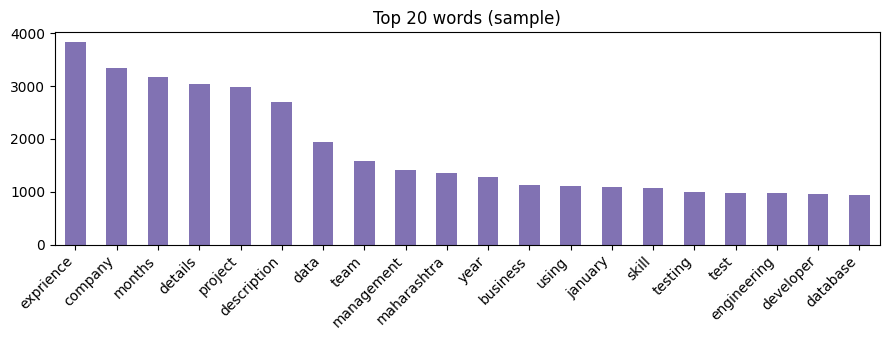

In [4]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
words=Counter()
for t in df['text'].astype(str).head(3000):
    words.update(w for w in t.lower().split() if w.isalpha() and w not in ENGLISH_STOP_WORDS and len(w)>2)
top=pd.Series(dict(words.most_common(20)))
fig,ax=plt.subplots(figsize=(9,3.5)); top.plot(kind='bar',ax=ax,color='#8172b3'); ax.set_title('Top 20 words (sample)'); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()

## 4. Sample documents per class

In [5]:
for lab in df['label'].unique()[:6]:
    s=df[df['label']==lab]['text'].iloc[0]
    print(f'[{lab}] '+str(s)[:160].replace(chr(10),' ')+'...\n')

[Data Science] Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯...

[HR] TECHNICAL SKILLS â¢ Typewriting â¢ TORA â¢ SPSSEducation Details  January 2017 MBA  Chidambaram, Tamil Nadu SNS College of Engineering January 2014 HSC   at ...

[Advocate] TECHNICAL QUALIFICATIONS: â¢ Windows, Ms. OfficeEducation Details   LL.B  Guwahati, Assam University Law College, Guwahati University  B.Sc  Jagiroad, ASSAM, I...

[Arts] â¢ Good communication skill â¢ Quick learner â¢ Keen to find solutionsEducation Details   MBA Marketing and International Business Management Pune, Maharasht...

[Web Designing] Technical Skills Web Technologies: Angular JS, HTML5, CSS3, SASS, Bootstrap, Jquery, Javascript. Software: Brackets, Visual Studio, Photoshop, Visual Studio Cod...

[Mechanical Engineer] Education Details  May 1999 to September 2002 Diploma Mechanical Engg Mumbai, Maharashtra Institute

## 5. Summary

The raw text and class balance above motivate the cleaning (notebook 02) and the TF-IDF + classic-ML modelling (notebook 03). Text length and vocabulary vary by class, which is exactly the signal the classifiers will exploit.